In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../..")

import sherlock as slk
from sherlock.benchmarks._runner import run_benchmark

In [2]:
data = slk.datasets.replogle()
print(data)

AnnData object with n_obs × n_vars = 118641 × 1185
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'treatment', 'pert'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'pathways'


In [3]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 681/681 [00:04<00:00, 152.72it/s]


In [4]:
cvae_res = run_benchmark(
    data,
    model="cvae",
    num_epochs=20,
    seed=0,
    treat_effect=data.uns["treat_effect"],
)
print(cvae_res)
print("cVAE metrics:", cvae_res.metrics)

Epochs: 100%|██████████| 20/20 [00:58<00:00,  2.93s/it, ate=0.1132, pat=0/20, r2=0.5260, train=1.7755, val=1.7789]

BenchmarkResult(model_name='cvae', model=cVAE(
  (p_emb): Embedding(682, 16)
  (dropout_layer): Dropout(p=0.0, inplace=False)
  (enc_fc1): Linear(in_features=1201, out_features=256, bias=True)
  (enc_fc2): Linear(in_features=256, out_features=256, bias=True)
  (enc_mu): Linear(in_features=256, out_features=16, bias=True)
  (enc_logvar): Linear(in_features=256, out_features=16, bias=True)
  (dec_fc1): Linear(in_features=32, out_features=256, bias=True)
  (dec_fc2): Linear(in_features=256, out_features=256, bias=True)
  (dec_out): Linear(in_features=256, out_features=1185, bias=True)
), metrics={'r2': 0.5260012149810791, 'ate': 0.11321510125399759, 'val_loss': 1.7789402802785237}, extras={'n_train': 106777, 'n_val': 11864, 'n_perts': 682, 'ntc_idx': 376})
cVAE metrics: {'r2': 0.5260012149810791, 'ate': 0.11321510125399759, 'val_loss': 1.7789402802785237}


In [5]:
scgen_res = run_benchmark(
    data,
    model="scgen",
    num_epochs=20,
    seed=0,
    treat_effect=data.uns["treat_effect"],
)

print(scgen_res.metrics)
print(scgen_res.extras["per_perturbation"])
print(scgen_res.extras["failures"])
print(scgen_res.extras["selected_holdouts"])

scGen holdouts: ['CCNK', 'GPS1', 'PSMG3', 'RPL3', 'RPS14', 'EEF2']


/Users/mahsa/azizi_lab/PerturbVAE/.venv/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/mahsa/azizi_lab/PerturbVAE/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[scGen benchmark] skipping RPL3: only 0 cells (< 30)
[scGen benchmark] skipping RPS14: only 0 cells (< 30)
[scGen benchmark] skipping EEF2: only 0 cells (< 30)
[scGen benchmark] requested holdouts: ['CCNK', 'GPS1', 'PSMG3', 'RPL3', 'RPS14', 'EEF2']
[scGen benchmark] selected holdouts after filtering: ['CCNK', 'GPS1', 'PSMG3']

[scGen benchmark] ---- running holdout: CCNK ----
[scGen benchmark] CCNK: n_train_ctrl=1600, n_test_ctrl=400, n_train_pert=597, n_test_pert=149


/Users/mahsa/azizi_lab/PerturbVAE/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training:   0%|          | 0/20 [00:00<?, ?it/s]

...

[scGen benchmark] finished: GPS1

[scGen benchmark] ---- running holdout: PSMG3 ----
[scGen benchmark] PSMG3: n_train_ctrl=1600, n_test_ctrl=400, n_train_pert=633, n_test_pert=158


/Users/mahsa/azizi_lab/PerturbVAE/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


[scGen benchmark] finished: PSMG3
{'r2': 0.9816545446713766, 'ate': 0.4856451822720786, 'val_loss': nan}
  perturbation        r2   pearson       ate  n_train_pert  n_test_pert  \
0         CCNK  0.977520  0.993858  0.554024           597          149   
1         GPS1  0.985169  0.994189  0.561291           537          134   
2        PSMG3  0.982274  0.996085  0.341620           633          158   

   n_train_ntc  n_test_ntc  delta_norm  
0         1600         400    4.044304  
1         1600         400    5.310041  
2         1600         400    7.722890  
Empty DataFrame
Columns: [perturbation, error]
Index: []
['CCNK', 'GPS1', 'PSMG3']


In [6]:
scgen_df = scgen_res.extras["per_perturbation"]
print(scgen_df)
print("num rows:", len(scgen_df))
print("perts:", scgen_df["perturbation"].tolist())

  perturbation        r2   pearson       ate  n_train_pert  n_test_pert  \
0         CCNK  0.977520  0.993858  0.554024           597          149   
1         GPS1  0.985169  0.994189  0.561291           537          134   
2        PSMG3  0.982274  0.996085  0.341620           633          158   

   n_train_ntc  n_test_ntc  delta_norm  
0         1600         400    4.044304  
1         1600         400    5.310041  
2         1600         400    7.722890  
num rows: 3
perts: ['CCNK', 'GPS1', 'PSMG3']


In [7]:
print(cvae_res.metrics)
print(scgen_res.metrics)
print(scgen_res.extras["per_perturbation"])

{'r2': 0.5260012149810791, 'ate': 0.11321510125399759, 'val_loss': 1.7789402802785237}
{'r2': 0.9816545446713766, 'ate': 0.4856451822720786, 'val_loss': nan}
  perturbation        r2   pearson       ate  n_train_pert  n_test_pert  \
0         CCNK  0.977520  0.993858  0.554024           597          149   
1         GPS1  0.985169  0.994189  0.561291           537          134   
2        PSMG3  0.982274  0.996085  0.341620           633          158   

   n_train_ntc  n_test_ntc  delta_norm  
0         1600         400    4.044304  
1         1600         400    5.310041  
2         1600         400    7.722890  


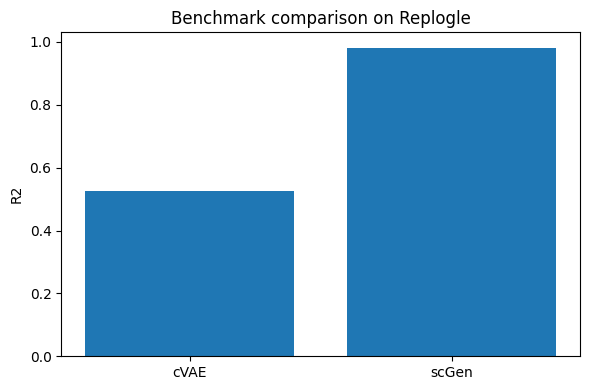

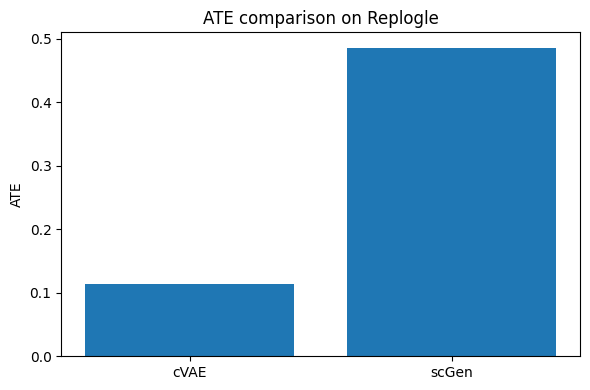

In [8]:
from sherlock.benchmarks import pl as bm_pl

summary = [
    {
        "model": "cVAE",
        "r2": cvae_res.metrics.get("r2", np.nan),
        "ate": cvae_res.metrics.get("ate", np.nan),
    },
    {
        "model": "scGen",
        "r2": scgen_res.metrics.get("r2", np.nan),
        "ate": scgen_res.metrics.get("ate", np.nan),
    },
]

bm_pl.plot_metric_summary(summary, metric="r2", title="Benchmark comparison on Replogle")
bm_pl.plot_metric_summary(summary, metric="ate", title="ATE comparison on Replogle")

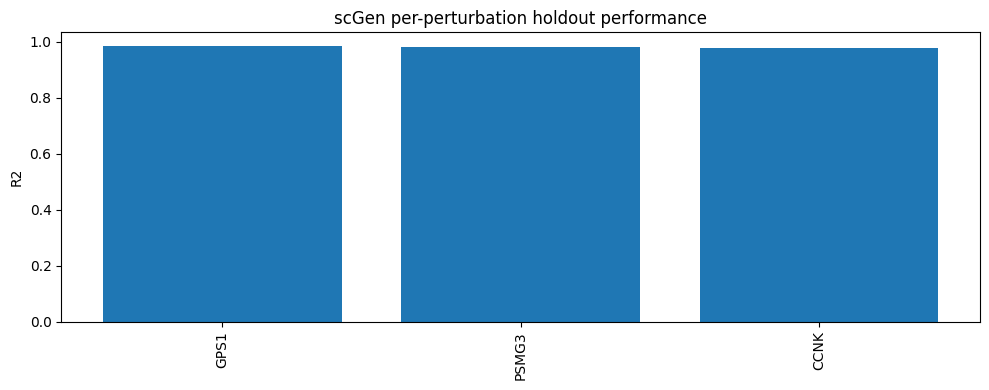

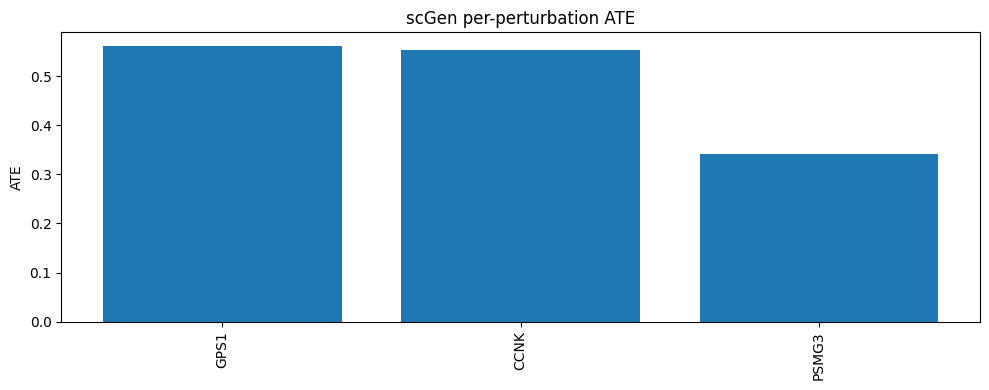

In [9]:
scgen_df = scgen_res.extras["per_perturbation"]

bm_pl.plot_per_perturbation_bar(
    scgen_df,
    metric="r2",
    title="scGen per-perturbation holdout performance",
)

bm_pl.plot_per_perturbation_bar(
    scgen_df,
    metric="ate",
    title="scGen per-perturbation ATE",
)